# **Training & Testing:**

This notebook contains the model training pipeline as well as model evaluation.

In [1]:
# Imports:
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq
from pathlib import Path

In [2]:
# Load in dataset:
df = pd.read_parquet("modeling_data.parquet", engine="pyarrow")

In [3]:
# Preview dataset:
df.head()

,first_careunit,admission_type_grouped,admission_location_grouped,insurance,language_grouped,marital_status,race_grouped,is_male,age,last_val_heart_rate,...,last_val_creatinine,last_val_wbc,min_val_platelets,last_val_sodium,max_val_sodium,min_val_sodium,max_val_potassium,min_val_potassium,max_val_bilirubin,ICU_mortality
0,Medical Intensive Care Unit (MICU),EMERGENCY,EMERGENCY,Medicare,ENGLISH,WIDOWED,WHITE,False,86,80.0,...,0.9,7.5,199.0,137.0,137.0,137.0,4.4,4.4,NaN,False
1,Surgical Intensive Care Unit (SICU),EMERGENCY,EMERGENCY,Private,NON-ENGLISH,MARRIED,WHITE,False,55,101.0,...,0.4,19.0,285.0,138.0,138.0,138.0,3.6,3.6,NaN,False
2,Medical/Surgical Intensive Care Unit (MICU/SICU),EMERGENCY,PROCEDURE,Private,ENGLISH,MARRIED,WHITE,False,46,84.0,...,0.8,20.1,299.0,138.0,140.0,138.0,3.9,3.5,NaN,False
3,Medical Intensive Care Unit (MICU),OBSERVATION,EMERGENCY,Medicare,ENGLISH,MARRIED,BLACK,False,77,78.0,...,1.0,12.0,149.0,138.0,138.0,134.0,4.2,3.9,0.4,True
4,Cardiac Vascular Intensive Care Unit (CVICU),SURGICAL,REFERRAL,Medicare,ENGLISH,SINGLE,OTHER,False,57,95.0,...,0.9,17.9,248.0,136.0,140.0,136.0,4.7,3.2,NaN,False


In [4]:
# More descriptive view of dataset:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 74583 entries, 0 to 74582
Data columns (total 26 columns):
 #   Column                      Non-Null Count  Dtype   
---  ------                      --------------  -----   
 0   first_careunit              74583 non-null  str     
 1   admission_type_grouped      74583 non-null  str     
 2   admission_location_grouped  74583 non-null  str     
 3   insurance                   74583 non-null  category
 4   language_grouped            74583 non-null  str     
 5   marital_status              74583 non-null  category
 6   race_grouped                74583 non-null  category
 7   is_male                     74583 non-null  bool    
 8   age                         74583 non-null  int32   
 9   last_val_heart_rate         74506 non-null  float64 
 10  max_val_heart_rate          74506 non-null  float64 
 11  mean_val_resp_rate          74369 non-null  float64 
 12  min_val_spo2                74486 non-null  float64 
 13  min_val_map                

In [5]:
# More descriptive view of dataset (cont.):
df.describe()

,age,last_val_heart_rate,max_val_heart_rate,mean_val_resp_rate,min_val_spo2,min_val_map,last_val_lactate,max_val_lactate,last_val_creatinine,last_val_wbc,min_val_platelets,last_val_sodium,max_val_sodium,min_val_sodium,max_val_potassium,min_val_potassium,max_val_bilirubin
count,74583.000000,74506.000000,74506.000000,74369.000000,74486.000000,74226.000000,44000.000000,4.400000e+04,73423.000000,73058.000000,73063.000000,73494.000000,73494.000000,73494.000000,73506.000000,73506.000000,33666.000000
mean,65.081842,84.307640,104.329159,24.350602,91.499037,58.487051,1.885439,3.173654e+01,1.436907,11.990368,195.039555,138.250184,139.431668,136.621733,4.532164,3.884557,2.030363
std,16.362802,17.769597,36.812859,1045.042367,6.652119,85.221702,1.473507,6.083570e+03,1.510104,8.510033,106.847240,4.871370,5.987676,5.315476,1.539617,0.555782,4.608716
min,18.000000,0.000000,36.000000,0.000000,-8.000000,-22767.000000,0.000000,0.000000e+00,0.000000,0.100000,5.000000,104.000000,107.000000,1.360000,2.200000,0.700000,0.000000
25%,55.000000,72.000000,89.000000,16.480000,90.000000,52.000000,1.100000,1.400000e+00,0.700000,7.700000,124.000000,136.000000,137.000000,134.000000,4.000000,3.500000,0.400000
50%,67.000000,83.000000,102.000000,18.600000,93.000000,60.000000,1.600000,2.100000e+00,1.000000,10.600000,179.000000,138.000000,139.000000,137.000000,4.400000,3.900000,0.700000
75%,77.000000,95.000000,117.000000,21.322581,95.000000,67.000000,2.100000,3.200000e+00,1.500000,14.400000,245.000000,141.000000,142.000000,140.000000,4.900000,4.200000,1.500000
max,103.000000,213.000000,6262.000000,269266.769231,100.000000,138.000000,26.300000,1.276103e+06,36.400000,378.300000,2001.000000,186.000000,1036.000000,177.000000,303.000000,8.400000,78.000000


## **Train/Test Split:**

Before we perform any data pre-processing, let's split the dataset into its train and test splits. 

In [6]:
# Imports:
from sklearn.model_selection import train_test_split, cross_val_score

In [7]:
# We're going to use the tradition 80-20 split:
target_col = 'ICU_mortality'

X = df.drop(columns=[target_col])
y = df[target_col].astype("int8")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [8]:
# Let's also separate columns based on their datatype for later pipelines:
cat_cols = X.select_dtypes(include=["object", "category"]).columns
num_cols = X.select_dtypes(include=["number"]).columns
bool_cols = X.select_dtypes(include=["bool"]).columns

/var/folders/pq/stz7tk255zb5f1gcbcvq5mf00000gp/T/ipykernel_66128/1031398442.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include=["object", "category"]).columns


## **Preprocessing Pipelines:**

In [9]:
# Imports: 
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

In [10]:
# Numerical pipeline:
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
    ("scaler", StandardScaler())
])

In [11]:
# Categorical pipeline:
cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

In [12]:
# Use passthrough for the boolean feature:
preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_cols),
    ("cat", cat_pipeline, cat_cols),
    ("bin", "passthrough", bool_cols)
])

In [13]:
# Double-check to make sure that we've actually handled every single column:
all_handled = set(num_cols) | set(cat_cols) | set(bool_cols)
print("Unassigned columns:", set(X.columns) - all_handled)

Unassigned columns: set()


## **Models:**

Note that for all these pipelines/models, we need to account for class imbalance in the target label. 

Furthermore, as a primary guideline for model evaluation, we should keep in mind that we're training these models to catch as many high-risk patients as possible. That is to say, we would rather misclassify a patient as high risk to prevent deaths. This means that our primary evaluation metric should be **recall** ("Of all patients who died, how many did we catch?"), and the lowest priority goes to **precision** ("Of all patients who we predicted to die, how many deaths were accurately forecasted?").

In [14]:
# Imports:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold, cross_validate, cross_val_predict
from sklearn.metrics import average_precision_score, classification_report, confusion_matrix, precision_recall_curve
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

### **Logistic Regression (Baseline):**

In [15]:
# Build the full pipeline for logistic regression:
full_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])

In [16]:
# Run N-fold CV:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision",
    "recall": "recall",
    "precision": "precision"
}

cv_scores = cross_validate(
    full_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring
)

# View fold-by-fold results:
cv_results_df = pd.DataFrame(cv_scores)
print(cv_results_df)

# Summary for just the test metrics:
metric_cols = [col for col in cv_results_df.columns if col.startswith("test_")]
print("\nMean CV metrics:")
print(cv_results_df[metric_cols].mean())

print("\nSTD CV metrics:")
print(cv_results_df[metric_cols].std())

   fit_time  score_time  test_roc_auc  test_pr_auc  test_recall  \
0  0.545287    0.054543      0.833944     0.349146     0.133411   
1  0.553672    0.046835      0.823201     0.337258     0.141531   
2  0.442357    0.046987      0.837483     0.381215     0.134571   
3  0.458922    0.051780      0.843054     0.380164     0.138051   
4  0.472912    0.048207      0.821624     0.332781     0.117169   

   test_precision  
0        0.631868  
1        0.606965  
2        0.648045  
3        0.646739  
4        0.627329  

Mean CV metrics:
test_roc_auc      0.831861
test_pr_auc       0.356113
test_recall       0.132947
test_precision    0.632189
dtype: float64

STD CV metrics:
test_roc_auc      0.009233
test_pr_auc       0.023222
test_recall       0.009375
test_precision    0.016756
dtype: float64


## **Random Forest:**

In [17]:
# Build the full pipeline for Random Forest:
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    ))
])

In [18]:
# Run N-fold CV:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision",
    "recall": "recall",
    "precision": "precision"
}

rf_cv_scores = cross_validate(
    rf_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring
)

# View fold-by-fold results:
rf_cv_results_df = pd.DataFrame(rf_cv_scores)
print(rf_cv_results_df)

# Summary for just the test metrics:
metric_cols = [col for col in rf_cv_results_df.columns if col.startswith("test_")]
print("\nMean CV metrics:")
print(rf_cv_results_df[metric_cols].mean())

print("\nSTD CV metrics:")
print(rf_cv_results_df[metric_cols].std())

   fit_time  score_time  test_roc_auc  test_pr_auc  test_recall  \
0  3.159164    0.211025      0.848747     0.364455     0.073086   
1  2.939707    0.207938      0.851973     0.360131     0.058005   
2  2.891156    0.210872      0.860838     0.393247     0.078886   
3  2.915829    0.201391      0.853204     0.384062     0.076566   
4  2.894263    0.202968      0.842535     0.339144     0.064965   

   test_precision  
0        0.724138  
1        0.641026  
2        0.755556  
3        0.767442  
4        0.658824  

Mean CV metrics:
test_roc_auc      0.851459
test_pr_auc       0.368208
test_recall       0.070302
test_precision    0.709397
dtype: float64

STD CV metrics:
test_roc_auc      0.006676
test_pr_auc       0.021227
test_recall       0.008666
test_precision    0.056898
dtype: float64


## **MLP Classifier (Neural Network):**

In [19]:
# Build the full pipeline for NN:
mlp_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", MLPClassifier(
        hidden_layer_sizes=(64, 32),
        activation="relu",
        solver="adam",
        alpha=0.0001,
        batch_size="auto",
        learning_rate_init=0.001,
        max_iter=300,
        early_stopping=True,
        validation_fraction=0.1,
        random_state=42
    ))
])

In [20]:
# Run N-fold CV:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision",
    "recall": "recall",
    "precision": "precision"
}

mlp_cv_scores = cross_validate(
    mlp_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring
)

# View fold-by-fold results:
mlp_cv_results_df = pd.DataFrame(mlp_cv_scores)
print(mlp_cv_results_df)

# Summary for just the test metrics:
metric_cols = [col for col in mlp_cv_results_df.columns if col.startswith("test_")]
print("\nMean CV metrics:")
print(mlp_cv_results_df[metric_cols].mean())

print("\nSTD CV metrics:")
print(mlp_cv_results_df[metric_cols].std())

   fit_time  score_time  test_roc_auc  test_pr_auc  test_recall  \
0  3.357471    0.059222      0.848046     0.376252     0.147332   
1  2.665337    0.055690      0.843494     0.374831     0.158933   
2  4.449965    0.053836      0.853406     0.405681     0.190255   
3  2.996333    0.053419      0.853789     0.412489     0.146172   
4  3.157834    0.056102      0.831001     0.358787     0.151972   

   test_precision  
0        0.654639  
1        0.611607  
2        0.609665  
3        0.754491  
4        0.603687  

Mean CV metrics:
test_roc_auc      0.845947
test_pr_auc       0.385608
test_recall       0.158933
test_precision    0.646818
dtype: float64

STD CV metrics:
test_roc_auc      0.009367
test_pr_auc       0.022630
test_recall       0.018214
test_precision    0.063512
dtype: float64


## **Result Review:**

**Logistic Regression:**

Mean CV metrics:
- test_roc_auc      0.845947
- test_pr_auc       0.385608
- test_recall       0.158933
- test_precision    0.646818

**Random Forest:**

Mean CV metrics:
- test_roc_auc      0.851459
- test_pr_auc       0.368208
- test_recall       0.070302
- test_precision    0.709397

**MLP Classifier (NN):**

Mean CV metrics:
- test_roc_auc      0.845947
- ntest_pr_auc       0.385608
- test_recall       0.158933
- test_precision    0.646818

Based on the results, and considering that we're prioritizing PR-AUC, Logistic Regression and MLP Classifier are our top performers. Furthermore, given that MLP is less interpretable than Logistic Regression, **we'll select Logistic Regression as our final model**.

## **Final Model Run:**

**Hyperparameter Tuning:**

In [32]:
# Imports:
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

In [33]:
# Rebuild LR pipeline:
lr_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])

# CV setup:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Hyperparameter space:
param_distributions = {
    "model__C": np.logspace(-3, 2, 20),
    "model__penalty": ["l2"],
    "model__solver": ["lbfgs"],
    "model__class_weight": [None, "balanced"]
}

# Randomized search:
lr_search = RandomizedSearchCV(
    estimator=lr_pipeline,
    param_distributions=param_distributions,
    n_iter=20,
    scoring="average_precision",   # PR-AUC
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

lr_search.fit(X_train, y_train)

print("Best params:", lr_search.best_params_)
print("Best CV PR-AUC:", lr_search.best_score_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best params: {'model__solver': 'lbfgs', 'model__penalty': 'l2', 'model__class_weight': None, 'model__C': np.float64(29.763514416313193)}
Best CV PR-AUC: 0.3562655016841171


**Thresholding:**

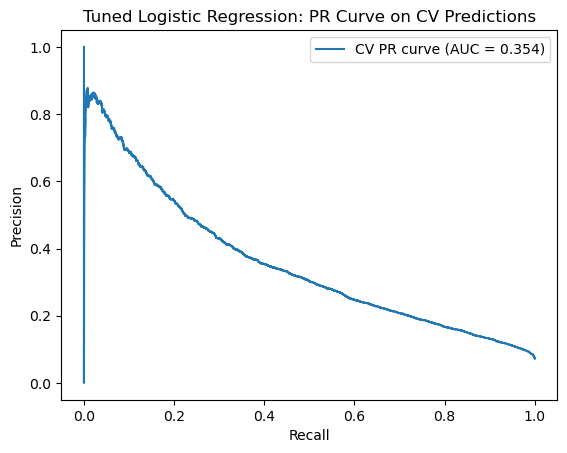

In [34]:
# Prioritize recall since we want to capture as many at-risk patients as possible, even if we're generating many false-positives:
best_lr_pipeline = lr_search.best_estimator_

# Out-of-fold predicted probabilities on the training set:
y_train_prob = cross_val_predict(
    best_lr_pipeline,
    X_train,
    y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

# PR curve on training CV predictions:
precision, recall, thresholds = precision_recall_curve(y_train, y_train_prob)
train_pr_auc = average_precision_score(y_train, y_train_prob)

plt.figure()
plt.plot(recall, precision, label=f"CV PR curve (AUC = {train_pr_auc:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Tuned Logistic Regression: PR Curve on CV Predictions")
plt.legend()
plt.show()

In [35]:
# Select a threshold systematically:
threshold_df = pd.DataFrame({
    "threshold": thresholds,
    "precision": precision[:-1],
    "recall": recall[:-1]
})

# Pick a target recall (can change later):
target_recall = 0.80

eligible = threshold_df[threshold_df["recall"] >= target_recall]

if eligible.empty:
    print("No threshold achieved the target recall.")
else:
    best_row = eligible.iloc[-1]   # Highest threshold that still meets recall target.
    chosen_threshold = best_row["threshold"]

    print("Chosen threshold row:")
    print(best_row)
    print("Chosen threshold:", chosen_threshold)

Chosen threshold row:
threshold    0.058705
precision    0.166965
recall       0.800000
Name: 39015, dtype: float64
Chosen threshold: 0.058704715580539024


**Fit & Evaluate:**

In [36]:
# Imports:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

In [37]:
# Fit the final tuned Logistic Regression model:
best_lr_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [38]:
# Evaluate the final tuned Logistic Regression model:
y_test_prob = best_lr_pipeline.predict_proba(X_test)[:, 1]
y_test_pred = (y_test_prob >= chosen_threshold).astype(int)

print("Test ROC-AUC:", roc_auc_score(y_test, y_test_prob))
print("Test PR-AUC:", average_precision_score(y_test, y_test_prob))
print("\nClassification report:")
print(classification_report(y_test, y_test_pred))
print("\nConfusion matrix:")
print(confusion_matrix(y_test, y_test_pred))

Test ROC-AUC: 0.8287821317716006
Test PR-AUC: 0.35609532201541155

Classification report:
              precision    recall  f1-score   support

           0       0.98      0.69      0.81     13844
           1       0.17      0.80      0.27      1073

    accuracy                           0.69     14917
   macro avg       0.57      0.74      0.54     14917
weighted avg       0.92      0.69      0.77     14917


Confusion matrix:
[[9497 4347]
 [ 213  860]]


## **Reports:**

In [40]:
# Imports:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

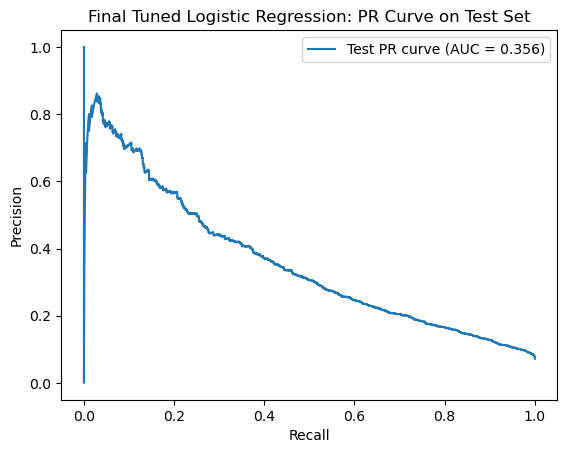

In [39]:
# PR-curve:
precision_test, recall_test, _ = precision_recall_curve(y_test, y_test_prob)
test_pr_auc = average_precision_score(y_test, y_test_prob)

plt.figure()
plt.plot(recall_test, precision_test, label=f"Test PR curve (AUC = {test_pr_auc:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Final Tuned Logistic Regression: PR Curve on Test Set")
plt.legend()
plt.show()

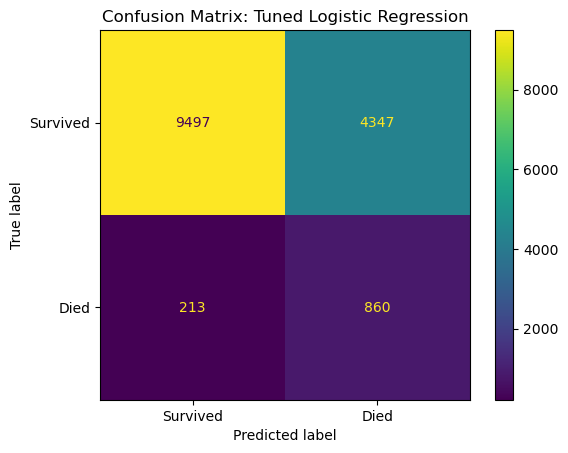

In [41]:
# Confusion matrix:
cm = confusion_matrix(y_test, y_test_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Survived", "Died"])
disp.plot(values_format="d")
plt.title("Confusion Matrix: Tuned Logistic Regression")
plt.show()

In [42]:
# Exact quantities for writeup:
tn, fp, fn, tp = cm.ravel()

print("TN:", tn)
print("FP:", fp)
print("FN:", fn)
print("TP:", tp)

recall_pos = tp / (tp + fn)
precision_pos = tp / (tp + fp)

print("Positive-class recall:", recall_pos)
print("Positive-class precision:", precision_pos)

TN: 9497
FP: 4347
FN: 213
TP: 860
Positive-class recall: 0.8014911463187325
Positive-class precision: 0.16516228154407528


**Summary & Interpretation:**

The final logistic regression model was evaluated using a threshold selected to prioritize recall. The chosen threshold of 0.059 is substantially lower than the default 0.5, reflecting the goal of identifying as many high-risk patients as possible.

At this threshold, the model achieved a recall of 0.80 for the mortality class, correctly identifying 860 out of 1,073 patients who died. This demonstrates strong sensitivity and aligns with the objective of minimizing missed high-risk patients.

However, this increased sensitivity comes at the cost of precision. The model’s precision for the positive class was 0.165, meaning that only 16.5% of patients flagged as high risk ultimately died. In total, 5,207 patients were flagged, of which 4,347 were false positives.

The confusion matrix highlights this tradeoff: while the number of false negatives (213) is relatively low, the number of false positives is substantial. Approximately 35% of all patients were classified as high risk in order to capture 80% of deaths.

This tradeoff may be acceptable in a clinical screening context, where failing to identify high-risk patients could have severe consequences. However, the practical usefulness of the model depends on whether the healthcare system can support interventions for a large number of patients who may not ultimately experience the outcome.